In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Laden der Rohdaten (stündliche Messwerte Nürnberg 1980–2024)
df = pd.read_csv("../03_app/data/../data/raw/data.csv")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)
elif "datum" in df.columns and "stunde" in df.columns:
    df["timestamp"] = pd.to_datetime(df["datum"]) + pd.to_timedelta(df["stunde"], unit="h")
    df.set_index("timestamp", inplace=True)

print(f"{len(df):,} Zeilen von {df.index.min().date()} bis {df.index.max().date()}")

394,488 Zeilen von 1980-01-01 bis 2024-12-31


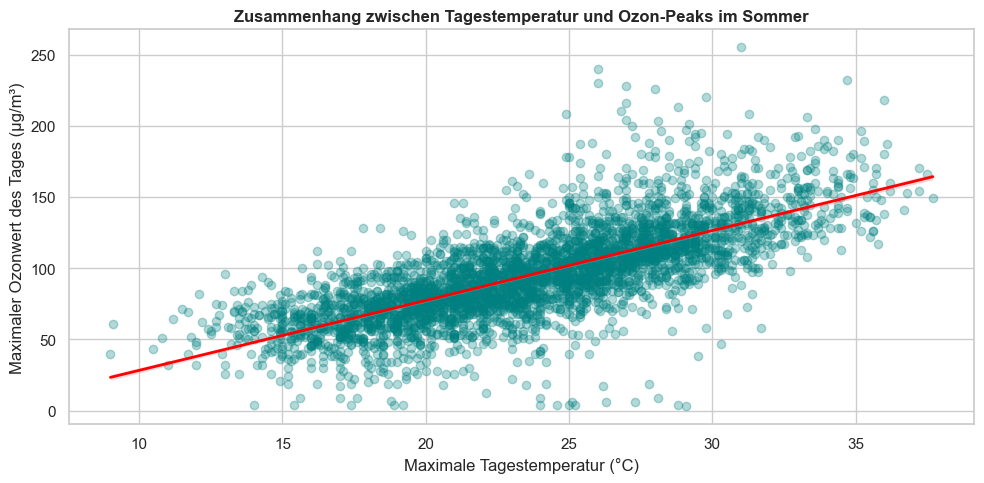

In [2]:
# Aggregation auf Sommermonate (Jun–Aug) – O₃-Spitzen konzentrieren sich in dieser Periode
df_sommer = df[df.index.month.isin([6, 7, 8])]
df_sommer_daily = df_sommer[["temperatur_2m", "o3"]].resample("D").max().dropna()

fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=df_sommer_daily, x="temperatur_2m", y="o3",
            scatter_kws={"alpha": 0.3, "color": "teal"},
            line_kws={"color": "red", "linewidth": 2}, ax=ax)
ax.set_title("Zusammenhang zwischen Tagestemperatur und Ozon-Peaks im Sommer",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Maximale Tagestemperatur (°C)")
ax.set_ylabel("Maximaler Ozonwert des Tages (µg/m³)")
plt.tight_layout()
plt.show()